In [53]:
import os
import pandas as pd

In [54]:
# Path to the folder containing all CSVs
DATA_FOLDER = '/Users/prasadpilankar/Documents/BAN/DE2025/Comtrade-Analytics/raw'  # Adjusted path
# DATA_FOLDER = './raw'  # Adjusted path
OUTPUT_FILE = 'merged_raw_trade.csv'
OUTPUT_Clean_FILE = 'cleandata_trade.csv'

In [55]:
# List all CSV files in the folder
csv_files = [f for f in os.listdir(DATA_FOLDER) if f.endswith('.csv') and f.startswith('TradeDataPlus')]

In [56]:
# df1 = pd.read_csv('/Users/prasadpilankar/Documents/BAN/DE2025/Comtrade-Analytics/raw/TradeDataPlus-08-12.csv', )
# df2 = pd.read_csv('/Users/prasadpilankar/Documents/BAN/DE2025/Comtrade-Analytics/raw/TradeDataPlus-12-24.csv')
# df1

In [57]:
# Read and concatenate all CSVs
all_dataframes = []
for file in csv_files:
    file_path = os.path.join(DATA_FOLDER, file)
    try:
        df = pd.read_csv(file_path, index_col=False, encoding='utf-8', low_memory=False)
        all_dataframes.append(df)
        print(f"Loaded: {file} with {df.shape[0]} rows.")
    except Exception as e:
        print(f"Error reading {file}: {e}")

# Merge all into one DataFrame
merged_raw_df = pd.concat(all_dataframes, ignore_index=True)

Loaded: TradeDataPlus-12-24.csv with 12773 rows.
Loaded: TradeDataPlus-08-12.csv with 5547 rows.


In [58]:
merged_raw_df

,typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,...,netWgt,isNetWgtEstimated,grossWgt,isGrossWgtEstimated,cifvalue,fobvalue,primaryValue,legacyEstimationFlag,isReported,isAggregate
0,C,A,20130101,2013,52,2013,36,AUS,Australia,M,...,NaN,False,NaN,False,NaN,1.051154e+09,1.051154e+09,0,True,False
1,C,A,20130101,2013,52,2013,56,BEL,Belgium,M,...,0.0,True,0.0,False,1.055977e+09,0.000000e+00,1.055977e+09,4,False,True
2,C,A,20130101,2013,52,2013,56,BEL,Belgium,X,...,0.0,True,0.0,False,0.000000e+00,1.401037e+09,1.401037e+09,4,False,True
3,C,A,20130101,2013,52,2013,76,BRA,Brazil,M,...,0.0,True,0.0,False,1.244719e+09,1.163276e+09,1.244719e+09,4,False,True
4,C,A,20130101,2013,52,2013,76,BRA,Brazil,X,...,0.0,True,0.0,False,NaN,4.506689e+08,4.506689e+08,4,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18315,C,A,20120101,2012,52,2012,826,GBR,United Kingdom,M,...,NaN,False,NaN,False,4.953160e+09,NaN,4.953160e+09,0,True,False
18316,C,A,20120101,2012,52,2012,842,USA,USA,M,...,NaN,False,NaN,False,5.600475e+10,NaN,5.600475e+10,0,True,False
18317,C,A,20120101,2012,52,2012,842,USA,USA,X,...,NaN,False,NaN,False,NaN,5.485363e+10,5.485363e+10,0,True,False
18318,C,A,20120101,2012,52,2012,826,GBR,United Kingdom,M,...,NaN,False,NaN,False,6.132945e+10,NaN,6.132945e+10,0,True,False


In [59]:
# Save the result
output_path = os.path.join(DATA_FOLDER, OUTPUT_FILE)
merged_raw_df.to_csv(output_path, index=False)
print(f"\n✅ Merged {len(csv_files)} files into: {OUTPUT_FILE} with {merged_raw_df.shape[0]} rows.")


✅ Merged 2 files into: merged_raw_trade.csv with 18320 rows.


In [60]:
missing_summary = merged_raw_df.isnull().sum().to_frame(name='Missing Count')
missing_summary['% Missing'] = (missing_summary['Missing Count'] / len(merged_raw_df) * 100).round(2)

# Completely empty rows
empty_rows = merged_raw_df[merged_raw_df.isnull().all(axis=1)].shape[0]

# Duplicate rows
duplicate_rows = merged_raw_df.duplicated().sum()

missing_summary_sorted = missing_summary.sort_values(by='% Missing', ascending=False)

missing_summary_sorted.head(10), empty_rows, duplicate_rows

(                Missing Count  % Missing
 qtyUnitAbbr             18320     100.00
 altQtyUnitAbbr          18320     100.00
 cifvalue                 8678      47.37
 netWgt                   8128      44.37
 grossWgt                 7719      42.13
 qty                      6152      33.58
 altQty                   6152      33.58
 fobvalue                 5719      31.22
 typeCode                    0       0.00
 isQtyEstimated              0       0.00,
 0,
 0)

In [61]:
merged_raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18320 entries, 0 to 18319
Data columns (total 47 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   typeCode                  18320 non-null  object 
 1   freqCode                  18320 non-null  object 
 2   refPeriodId               18320 non-null  int64  
 3   refYear                   18320 non-null  int64  
 4   refMonth                  18320 non-null  int64  
 5   period                    18320 non-null  int64  
 6   reporterCode              18320 non-null  int64  
 7   reporterISO               18320 non-null  object 
 8   reporterDesc              18320 non-null  object 
 9   flowCode                  18320 non-null  object 
 10  flowDesc                  18320 non-null  object 
 11  partnerCode               18320 non-null  int64  
 12  partnerISO                18320 non-null  object 
 13  partnerDesc               18320 non-null  object 
 14  partne

In [62]:
# Define the relevant columns to keep
relevant_columns = [
    'refPeriodId', 'freqCode', 'typeCode', 'refYear','refMonth','' 'reporterISO', 'reporterDesc',
    'partnerISO', 'partnerDesc','classificationCode','aggrLevel','isLeaf',  'mosCode', 'motCode',
    'flowCode', 'cmdCode', 'cmdDesc',
    'qty', 'netWgt', 'cifvalue', 'fobvalue','primaryValue',
    'isReported'
]

# Keep only the relevant columns that exist in the file
existing_columns = [col for col in relevant_columns if col in merged_raw_df.columns]
df_cleaned = merged_raw_df[existing_columns].copy()

# Clean column names (optional: lowercased, underscored)
df_cleaned.columns = df_cleaned.columns.str.strip().str.lower().str.replace(' ', '_')

# Handle missing values in key numeric fields
for col in ['qty', 'netwgt', 'cifvalue', 'fobvalue']:
    if col in df_cleaned.columns:
        df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors='coerce').fillna(0)

In [63]:
df_cleaned

,refperiodid,freqcode,typecode,refyear,refmonth,reporteriso,reporterdesc,partneriso,partnerdesc,classificationcode,...,motcode,flowcode,cmdcode,cmddesc,qty,netwgt,cifvalue,fobvalue,primaryvalue,isreported
0,20130101,A,C,2013,52,AUS,Australia,AUS,Australia,H4,...,0,M,TOTAL,All Commodities,0.0,0.0,0.000000e+00,1.051154e+09,1.051154e+09,True
1,20130101,A,C,2013,52,BEL,Belgium,AUS,Australia,H4,...,0,M,TOTAL,All Commodities,0.0,0.0,1.055977e+09,0.000000e+00,1.055977e+09,False
2,20130101,A,C,2013,52,BEL,Belgium,AUS,Australia,H4,...,0,X,TOTAL,All Commodities,0.0,0.0,0.000000e+00,1.401037e+09,1.401037e+09,False
3,20130101,A,C,2013,52,BRA,Brazil,AUS,Australia,H4,...,0,M,TOTAL,All Commodities,0.0,0.0,1.244719e+09,1.163276e+09,1.244719e+09,False
4,20130101,A,C,2013,52,BRA,Brazil,AUS,Australia,H4,...,0,X,TOTAL,All Commodities,0.0,0.0,0.000000e+00,4.506689e+08,4.506689e+08,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18315,20120101,A,C,2012,52,GBR,United Kingdom,GBR,United Kingdom,H4,...,0,M,TOTAL,All Commodities,0.0,0.0,4.953160e+09,0.000000e+00,4.953160e+09,True
18316,20120101,A,C,2012,52,USA,USA,GBR,United Kingdom,H4,...,0,M,TOTAL,All Commodities,0.0,0.0,5.600475e+10,0.000000e+00,5.600475e+10,True
18317,20120101,A,C,2012,52,USA,USA,GBR,United Kingdom,H4,...,0,X,TOTAL,All Commodities,0.0,0.0,0.000000e+00,5.485363e+10,5.485363e+10,True
18318,20120101,A,C,2012,52,GBR,United Kingdom,USA,USA,H4,...,0,M,TOTAL,All Commodities,0.0,0.0,6.132945e+10,0.000000e+00,6.132945e+10,True


In [64]:
df_cleaned = df_cleaned.sort_values(by='refyear')
df_cleaned

,refperiodid,freqcode,typecode,refyear,refmonth,reporteriso,reporterdesc,partneriso,partnerdesc,classificationcode,...,motcode,flowcode,cmdcode,cmddesc,qty,netwgt,cifvalue,fobvalue,primaryvalue,isreported
13883,20080101,A,C,2008,52,GBR,United Kingdom,USA,USA,H3,...,0,X,TOTAL,All Commodities,0.0,0.0,0.000000e+00,6.516829e+10,6.516829e+10,True
13505,20080101,A,C,2008,52,SAU,Saudi Arabia,GBR,United Kingdom,H3,...,0,X,TOTAL,All Commodities,0.0,0.0,0.000000e+00,3.446034e+08,3.446034e+08,True
13506,20080101,A,C,2008,52,NLD,Netherlands,USA,USA,H3,...,0,M,TOTAL,All Commodities,0.0,0.0,3.995590e+10,0.000000e+00,3.995590e+10,True
13507,20080101,A,C,2008,52,NLD,Netherlands,USA,USA,H3,...,0,X,TOTAL,All Commodities,0.0,0.0,0.000000e+00,2.429345e+10,2.429345e+10,True
13508,20080101,A,C,2008,52,NGA,Nigeria,USA,USA,H2,...,0,M,TOTAL,All Commodities,0.0,0.0,2.313078e+09,0.000000e+00,2.313078e+09,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12341,20240101,A,C,2024,52,DEU,Germany,IND,India,H6,...,0,M,TOTAL,All Commodities,0.0,0.0,1.542689e+10,0.000000e+00,1.542689e+10,False
12342,20240101,A,C,2024,52,DEU,Germany,IND,India,H6,...,0,X,TOTAL,All Commodities,0.0,0.0,0.000000e+00,1.843219e+10,1.843219e+10,False
12343,20240101,A,C,2024,52,DEU,Germany,SGP,Singapore,H6,...,0,M,TOTAL,All Commodities,0.0,0.0,5.282223e+09,0.000000e+00,5.282223e+09,False
12325,20240101,A,C,2024,52,DEU,Germany,ITA,Italy,H6,...,0,M,TOTAL,All Commodities,0.0,0.0,7.383448e+10,0.000000e+00,7.383448e+10,False


In [65]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 18320 entries, 13883 to 12771
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   refperiodid         18320 non-null  int64  
 1   freqcode            18320 non-null  object 
 2   typecode            18320 non-null  object 
 3   refyear             18320 non-null  int64  
 4   refmonth            18320 non-null  int64  
 5   reporteriso         18320 non-null  object 
 6   reporterdesc        18320 non-null  object 
 7   partneriso          18320 non-null  object 
 8   partnerdesc         18320 non-null  object 
 9   classificationcode  18320 non-null  object 
 10  aggrlevel           18320 non-null  int64  
 11  isleaf              18320 non-null  bool   
 12  moscode             18320 non-null  int64  
 13  motcode             18320 non-null  int64  
 14  flowcode            18320 non-null  object 
 15  cmdcode             18320 non-null  object 
 16  

In [66]:
import seaborn as sns

# Summary statistics for numeric columns
numeric_summary = df_cleaned.describe()
numeric_summary

,refperiodid,refyear,refmonth,aggrlevel,moscode,motcode,qty,netwgt,cifvalue,fobvalue,primaryvalue
count,1.832000e+04,18320.000000,18320.0,18320.0,18320.0,18320.0,18320.0,18320.0,1.832000e+04,1.832000e+04,1.832000e+04
mean,2.015778e+07,2015.767631,52.0,0.0,0.0,0.0,0.0,0.0,8.046672e+09,1.011067e+10,1.745292e+10
std,4.779817e+04,4.779817,0.0,0.0,0.0,0.0,0.0,0.0,2.843866e+10,3.371211e+10,4.070946e+10
min,2.008010e+07,2008.000000,52.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,1.100000e-02
25%,2.012010e+07,2012.000000,52.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,1.702723e+09
50%,2.016010e+07,2016.000000,52.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,9.851939e+08,4.836162e+09
75%,2.020010e+07,2020.000000,52.0,0.0,0.0,0.0,0.0,0.0,4.199682e+09,5.847157e+09,1.512268e+10
max,2.024010e+07,2024.000000,52.0,0.0,0.0,0.0,0.0,0.0,5.756881e+11,5.827561e+11,5.827561e+11


In [67]:
# Unique values and counts for categorical columns
categorical_summary = {col: df_cleaned[col].value_counts() for col in df_cleaned.select_dtypes(include=['object', 'bool']).columns}

# Check for missing values
missing_values = df_cleaned.isnull().sum()

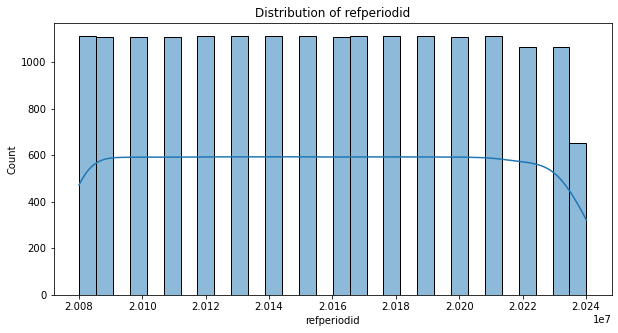

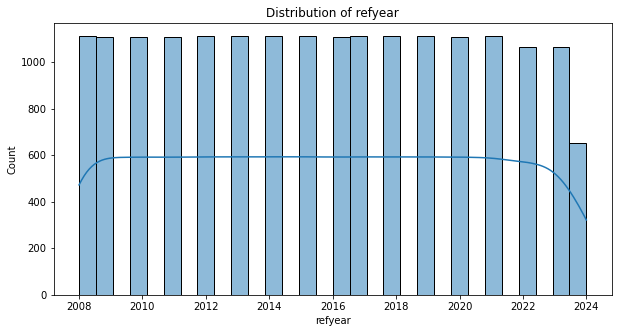

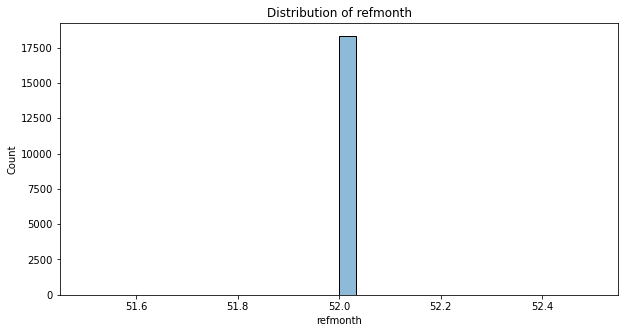

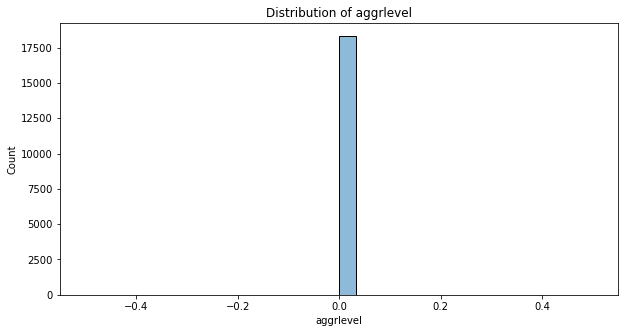

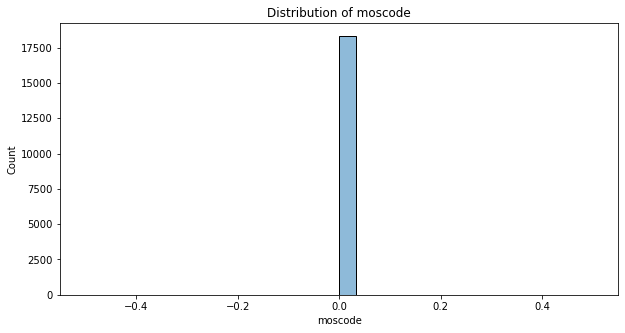

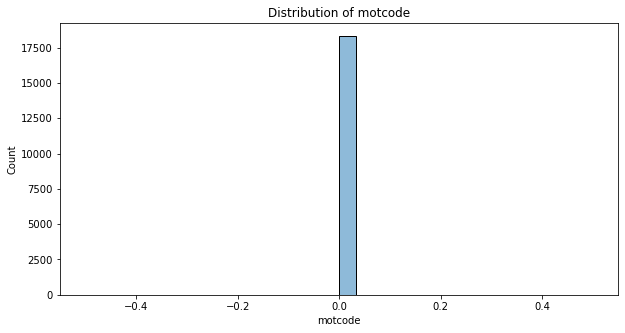

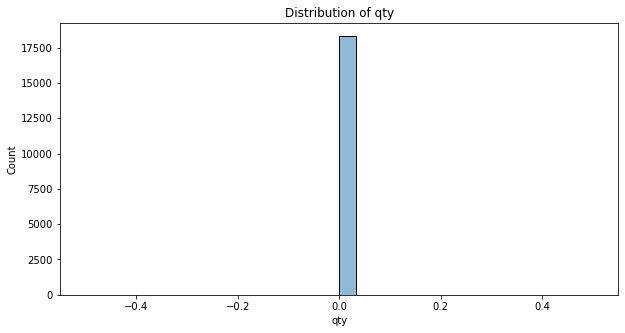

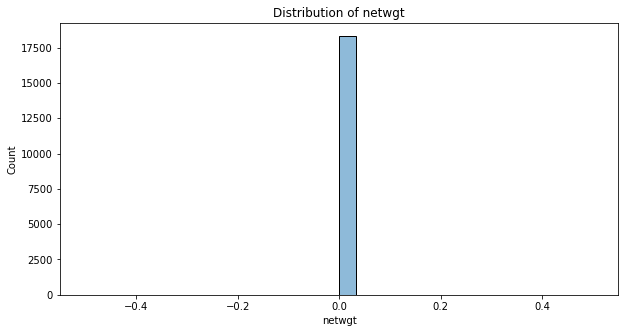

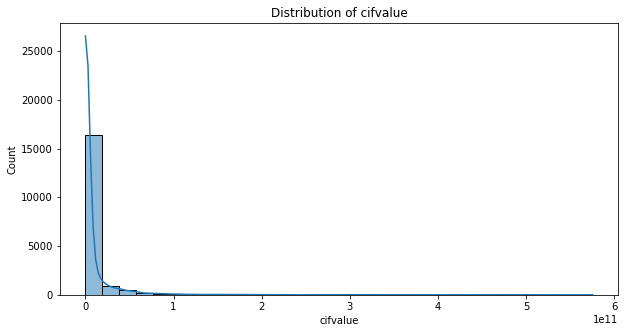

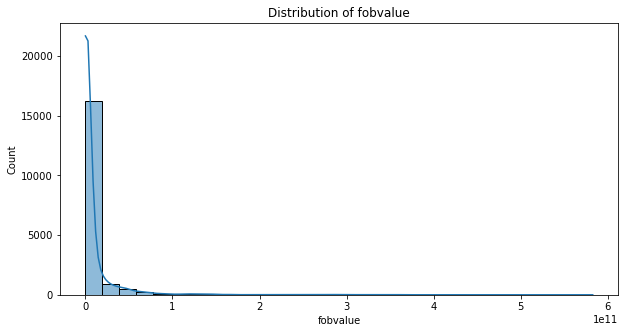

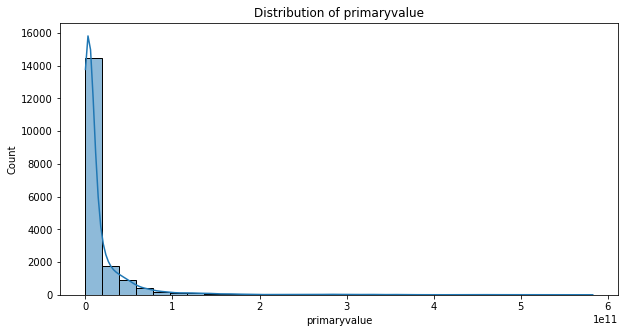

In [68]:
# Distribution of numeric columns
import matplotlib.pyplot as plt

for col in df_cleaned.select_dtypes(include=['float64', 'int64']).columns:
    plt.figure(figsize=(10, 5))
    sns.histplot(df_cleaned[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.show()

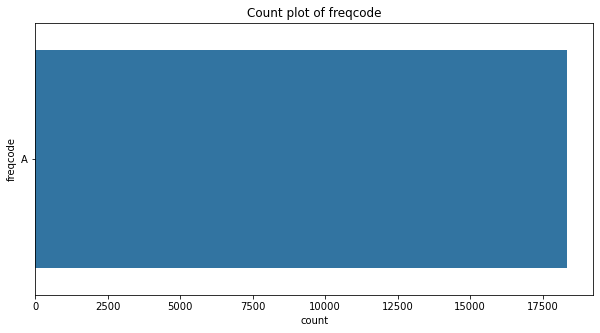

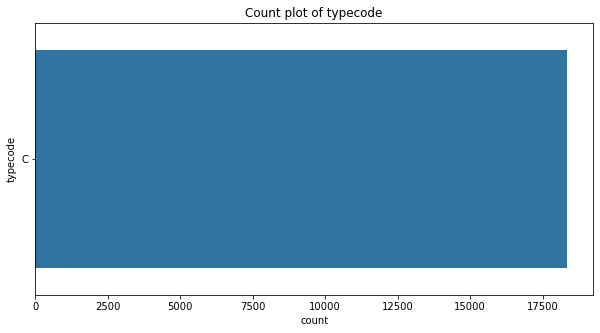

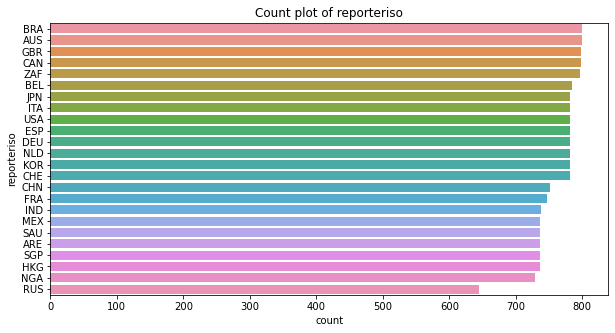

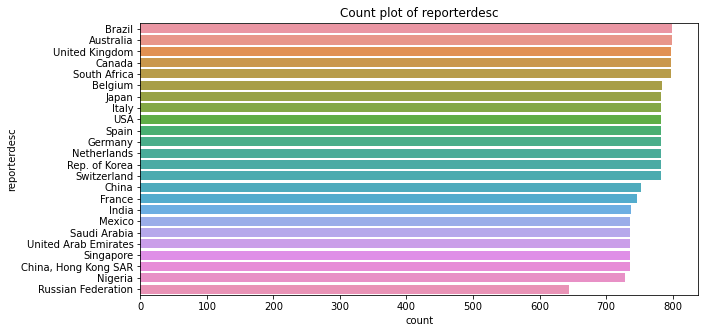

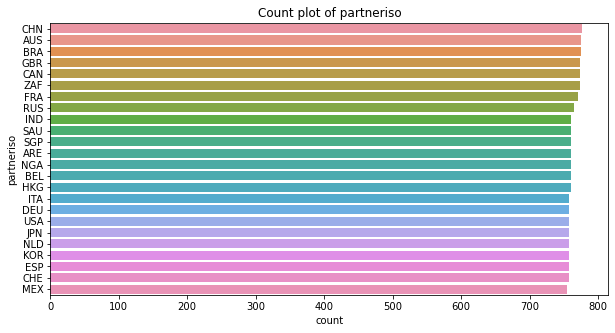

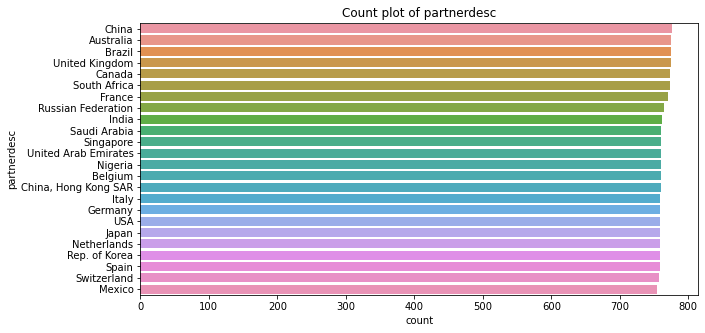

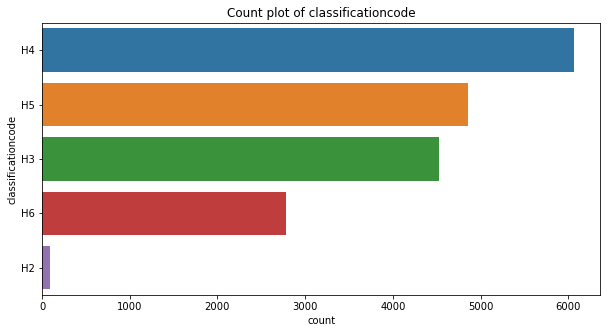

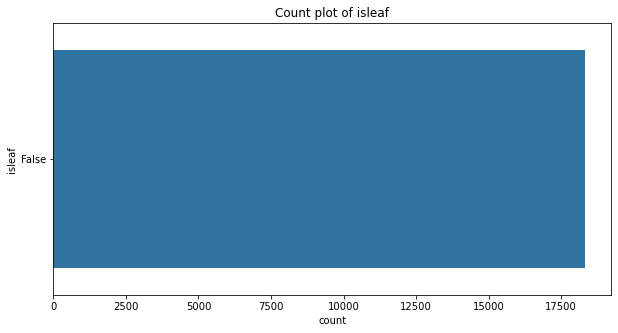

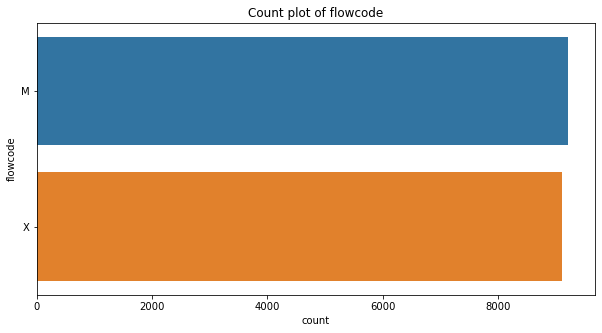

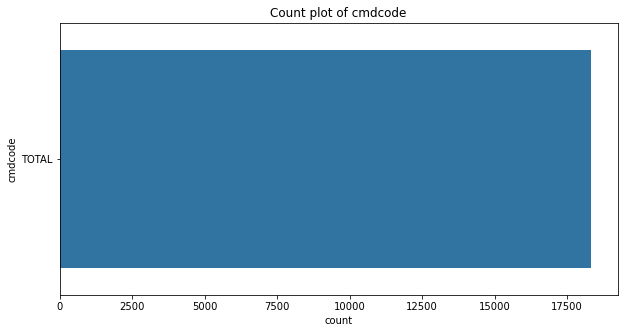

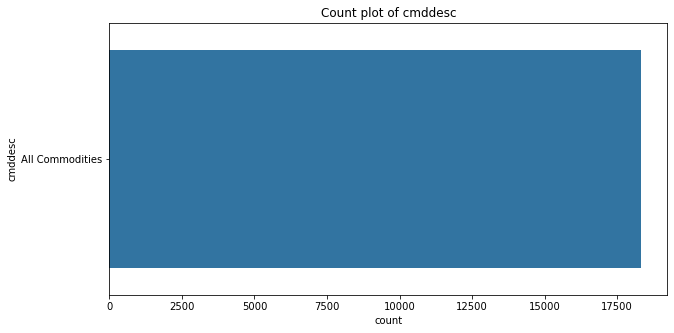

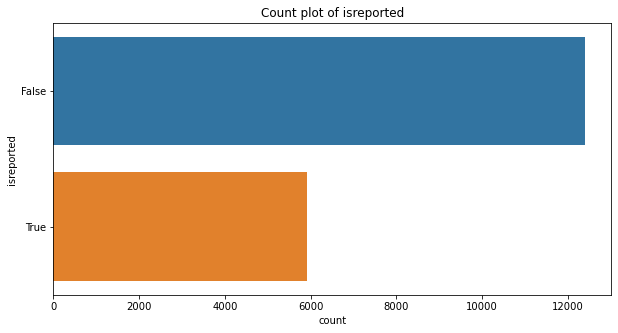

<ipython-input-69-bb6dea72559c>:10: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df_cleaned.corr(), annot=True, fmt=".2f", cmap="coolwarm")
/Users/prasadpilankar/anaconda3/lib/python3.11/site-packages/seaborn/matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


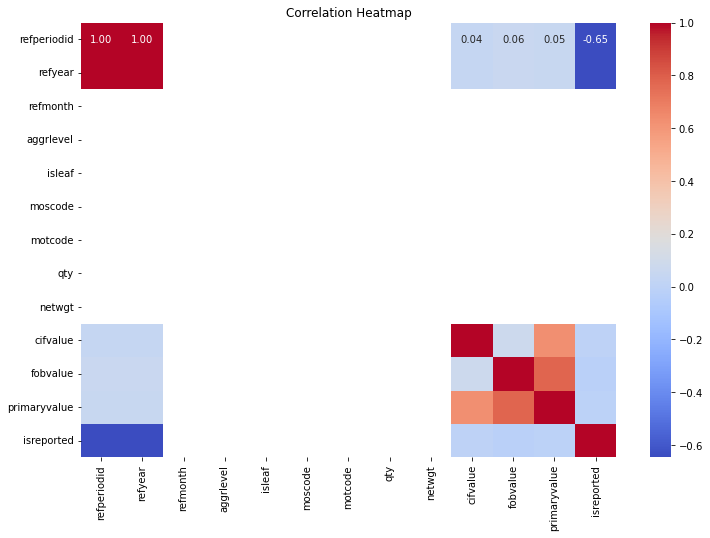

In [69]:
# Count plots for categorical columns
for col in df_cleaned.select_dtypes(include=['object', 'bool']).columns:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df_cleaned, y=col, order=df_cleaned[col].value_counts().index)
    plt.title(f'Count plot of {col}')
    plt.show()

# Correlation heatmap for numeric columns
plt.figure(figsize=(12, 8))
sns.heatmap(df_cleaned.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [70]:
df_cleaned.to_csv(OUTPUT_Clean_FILE, index=False)